# Генератор пользовательских данных для подсчета клеток крови

## HT_3:
### Преобразование Фурье:
1. Преобразовать исходный генератор данных. Добавить возможность добавления периодического шума.
2. Удалить периодический шум при помощи преобразования Фурье.
3. Измерить показатели качества при помощи преобразования Фурье.
### Сжатие данных при помощи вейвлет-преобразования:
1. Исходное изображение в оттенках серого кодируется в текстовом файле попиксельной записью интенсивности. 
    - RLE: Каждое значимое значение хранится парой чисел: (количество нулей перед ним, само значение)
2. Реализовать вейвлет-преобразование Хаара.
3. Удалить высокочастотные составляющие с низкими детализирующими коэффициентами.
4. Закодировать данные при помощи RLE алгоритма.
5. Сохранить получившиеся данные.
6. Определить степень сжатия (среднюю для набора изображений). Отношение объема файла до/после сжатия.

In [2]:
# настройка окружения
import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from typing import Tuple, List
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error
import scipy.fftpack as fftpack

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 8

In [3]:
def load_bccd_patches_to_ram(bccd_img_dir: str, bccd_mask_dir: str, patch_size=64):
    bg_patches, cell_patches = [], []
    
    if not os.path.exists(bccd_img_dir) or not os.path.exists(bccd_mask_dir):
        print(f"[WARN] Папки не найдены. Будет использована только синтетика.")
        return bg_patches, cell_patches

    print("Быстрая нарезка датасета...")
    mask_files = os.listdir(bccd_mask_dir)
    mask_dict = {os.path.splitext(f)[0]: f for f in mask_files}
    
    for img_name in os.listdir(bccd_img_dir):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img = cv2.imread(os.path.join(bccd_img_dir, img_name))
        if img is None: continue
        
        base_name = os.path.splitext(img_name)[0]
        if base_name not in mask_dict: continue
            
        mask = cv2.imread(os.path.join(bccd_mask_dir, mask_dict[base_name]), cv2.IMREAD_GRAYSCALE)
        if mask is None: continue
        
        _, mask_bin = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
        h, w = img.shape[:2]
        step = patch_size // 2 
        
        for y in range(0, h - patch_size + 1, step):
            for x in range(0, w - patch_size + 1, step):
                p_mask = mask_bin[y:y+patch_size, x:x+patch_size]
                p_img = img[y:y+patch_size, x:x+patch_size]
                
                cell_pixels = np.sum(p_mask > 0)
                total_pixels = patch_size * patch_size
                
                if cell_pixels > total_pixels * 0.5:
                    cell_patches.append(p_img.copy())
                elif cell_pixels == 0:
                    bg_patches.append(p_img.copy())
                    
    print(f"Загружено: {len(bg_patches)} фонов, {len(cell_patches)} клеток.")
    return bg_patches, cell_patches


In [4]:
# Модификация класса BloodCellDataset для поддержки периодического шума
class BloodCellDataset(Dataset):
    def __init__(self, img_size: Tuple[int, int], dataset_size: int, 
                 bg_patches: List[np.ndarray], cell_patches: List[np.ndarray], 
                 noise_type: str = 'gaussian', use_synthetic: bool = True,
                 periodic_freq: int = 20, periodic_amplitude: int = 25):
        super().__init__()
        self.image_size = img_size
        self.dataset_size = dataset_size
        self.noise_type = noise_type
        self.use_synthetic = use_synthetic
        self.bg_patches = bg_patches
        self.cell_patches = cell_patches
        self.bg_colors = [(220, 200, 200), (240, 220, 210), (210, 190, 195)]
        self.cell_colors = [(80, 60, 120), (160, 80, 100), (100, 100, 160)]
        # Параметры периодического шума
        # self.periodic_freq = periodic_freq
        # self.periodic_amplitude = periodic_amplitude

    def __len__(self) -> int: 
        return self.dataset_size

    def __getitem__(self, idx: int) -> Tuple[np.ndarray, np.ndarray, int]:
        h, w = self.image_size
        
        # Генерация фона
        if random.random() < 0.5 and len(self.bg_patches) > 0:
            patch = random.choice(self.bg_patches)
            bg = cv2.resize(patch, (w, h))
        elif self.use_synthetic:
            bg = np.full((h, w, 3), random.choice(self.bg_colors), dtype=np.uint8)
        else:
            bg = np.zeros((h, w, 3), dtype=np.uint8)
        bg = cv2.GaussianBlur(bg, (3, 3), 0)
        
        # Генерация клеток
        count = random.randint(3, 10)
        for _ in range(count):
            cell_size = random.randint(16, 40)
            margin = cell_size // 2 + 10 
            x = random.randint(margin, w - margin - cell_size)
            y = random.randint(margin, h - margin - cell_size)
            cell, mask = self._get_cell(cell_size)
            if cell is None: continue
            center = (x + cell_size // 2, y + cell_size // 2)
            try:
                bg = cv2.seamlessClone(cell, bg, mask, center, cv2.NORMAL_CLONE)
            except Exception: pass 

        clean_img = bg
        
        # Добавление шума в зависимости от выбранного типа
        # if self.noise_type == 'periodic':
            # Добавляем периодический шум
        #    noisy_img = add_periodic_noise(clean_img, 
        #                                   freq=self.periodic_freq, 
        #                                   amplitude=self.periodic_amplitude)
        # else:
            # Добавляем случайный шум (гауссовский или равномерный)
        noisy_img = self._add_noise(clean_img)
            
        return clean_img, noisy_img, count

    def _get_cell(self, size):
        if random.random() < 0.5 and len(self.cell_patches) > 0:
            cell = random.choice(self.cell_patches)
            cell = cv2.resize(cell, (size, size))
            mask = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
            _, mask = cv2.threshold(mask, 10, 255, cv2.THRESH_BINARY)
        elif self.use_synthetic:
            cell = np.zeros((size, size, 3), dtype=np.uint8)
            cv2.circle(cell, (size//2, size//2), size//2 - 2, random.choice(self.cell_colors), -1)
            mask = np.zeros((size, size), dtype=np.uint8)
            cv2.circle(mask, (size//2, size//2), size//2 - 2, 255, -1)
        else: return None, None
        return cell, mask

    def _add_noise(self, img):
        noisy = img.copy().astype(np.float32)
        row, col, ch = img.shape

        if self.noise_type == 'gaussian':
            noise = np.random.normal(0, 20, (row, col, ch))
        elif self.noise_type == 'uniform':
            noise = np.random.uniform(-50, 50, (row, col, ch))
        elif self.noise_type == 'periodic':
            amp=30
            freq_x=12
            freq_y=18
            h, w = img.shape[:2]
            x = np.arange(w)
            y = np.arange(h)
            X, Y = np.meshgrid(x, y)
            noise = (
                amp * np.sin(2*np.pi*freq_x*X/w) +
                0.7 * amp * np.sin(2*np.pi*freq_y*Y/h)
            )
            noisy = img.astype(np.float32) + noise[..., None]
            return np.clip(noisy, 0, 255).astype(np.uint8)
        else:
            return img
            
        return np.clip(noisy + noise, 0, 255).astype(np.uint8)


In [5]:
# Вспомогательная функция для конвертации BGR (OpenCV) в RGB (Matplotlib)
def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [ ]:
def remove_periodic_noise_fft(noisy_img, freq_x=12, freq_y=18, notch_radius=3):

   h, w = noisy_img.shape[:2]
   cy, cx = h // 2, w // 2
   mask = np.ones((h, w), np.float32)
   Y, X = np.ogrid[:h, :w]
   notch_points = [
       (cy, cx + freq_x),
       (cy, cx - freq_x),
       (cy + freq_y, cx),
       (cy - freq_y, cx)
   ]

   for py, px in notch_points:
       dist2 = (Y - py) ** 2 + (X - px) ** 2
       notch = 1 - np.exp(-dist2 / (2 * notch_radius ** 2))
       mask *= notch

   result = np.zeros_like(noisy_img)

   for c in range(3):
       f = np.fft.fftshift(
           np.fft.fft2(noisy_img[:, :, c].astype(np.float32))
       )

       filtered = f * mask
       restored = np.fft.ifft2(np.fft.ifftshift(filtered)).real
       result[:, :, c] = np.clip(restored, 0, 255)

   return result.astype(np.uint8)

In [7]:
def compute_fourier_metrics(clean_img, denoised_img):

    # Преобразование в оттенки серого
    if len(clean_img.shape) == 3:
        clean_gray = cv2.cvtColor(clean_img, cv2.COLOR_BGR2GRAY)
    else:
        clean_gray = clean_img.copy()
        
    if len(denoised_img.shape) == 3:
        denoised_gray = cv2.cvtColor(denoised_img, cv2.COLOR_BGR2GRAY)
    else:
        denoised_gray = denoised_img.copy()
    
    # Вычисление спектров
    f_clean = np.fft.fft2(clean_gray)
    f_denoised = np.fft.fft2(denoised_gray)
    
    # 1. SNR в частотной области (дБ)
    power_clean = np.sum(np.abs(f_clean)**2)
    power_noise = np.sum(np.abs(f_clean - f_denoised)**2)
    snr_db = 10 * np.log10(power_clean / (power_noise + 1e-10))
    
    # 2. MSE между спектрами
    mse_spectrum = np.mean((np.abs(f_clean) - np.abs(f_denoised))**2)
    
    # 3. Корреляция спектров
    correlation = np.corrcoef(np.abs(f_clean).flatten(), 
                              np.abs(f_denoised).flatten())[0, 1]
    
    return {
        'snr_db': snr_db,
        'mse_spectrum': mse_spectrum,
        'correlation': correlation
    }

In [8]:
# Интеграция в бенчмарк
def run_benchmark(bg_patches, cell_patches, noise_type='periodic'):
    IMG_SIZE = (128, 128)
    NUM_IMAGES = 100  # 50
    
    filters = {
        'Median (3x3)': lambda img: cv2.medianBlur(img, 3),
        'Median (5x5)': lambda img: cv2.medianBlur(img, 5),
        'Gaussian (3x3)': lambda img: cv2.GaussianBlur(img, (3, 3), 0),
        'Gaussian (5x5)': lambda img: cv2.GaussianBlur(img, (5, 5), 0),
        'Bilateral (d=9)': lambda img: cv2.bilateralFilter(img, 9, 75, 75),
        'Bilateral (d=15)': lambda img: cv2.bilateralFilter(img, 15, 100, 100),
        'NLM (h=10)': lambda img: cv2.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21),
        'NLM (h=20)': lambda img: cv2.fastNlMeansDenoisingColored(img, None, 20, 20, 7, 21),
        'NLM (h=30)': lambda img: cv2.fastNlMeansDenoisingColored(img, None, 30, 30, 7, 21),
        'FFT Notch Filter': lambda img: remove_periodic_noise_fft(img, ) 
    }

    results = {fn: {'ssim': [], 'mse': [], 'snr_db': [], 'mse_spectrum': []} for fn in filters}

    print(f"\n[ОЦЕНКА] Генерация и фильтрация {NUM_IMAGES} изображений (шум: {noise_type})...")
    dataset = BloodCellDataset(
        img_size=IMG_SIZE, dataset_size=NUM_IMAGES,
        bg_patches=bg_patches, cell_patches=cell_patches,
        noise_type=noise_type, use_synthetic=True,
        periodic_freq=50, periodic_amplitude=30 # Параметры для периодического шума
    )

    for i in range(len(dataset)):
        clean_img, noisy_img, _ = dataset[i]
        for f_name, f_func in filters.items():
            denoised_img = f_func(noisy_img)
            # Стандартные метрики
            results[f_name]['ssim'].append(ssim(clean_img, denoised_img, channel_axis=-1, data_range=255))
            results[f_name]['mse'].append(mean_squared_error(clean_img, denoised_img))
            # Новые метрики на основе FFT
            fourier_metrics = compute_fourier_metrics(clean_img, denoised_img)
            results[f_name]['snr_db'].append(fourier_metrics['snr_db'])
            results[f_name]['mse_spectrum'].append(fourier_metrics['mse_spectrum'])

    # Вывод результатов
    print(f"\n{'='*100}")
    print(f"РЕЗУЛЬТАТЫ ДЛЯ ШУМА: {noise_type.upper()}")
    print(f"{'='*100}")
    print(f"{'Фильтр':<20} | {'SSIM':<8} | {'MSE':<8} | {'SNR (дБ)':<10} | {'MSE Spectrum':<15}")
    print("-" * 80)
    
    best_ssim_n, best_ssim_v = "", -1.0
    best_mse_n, best_mse_v = "", float('inf')
    best_snr_n, best_snr_v = "", -float('inf')
    
    for f_name, metrics in results.items():
        avg_s = np.mean(metrics['ssim'])
        avg_m = np.mean(metrics['mse'])
        avg_snr = np.mean(metrics['snr_db'])
        avg_mse_spectrum = np.mean(metrics['mse_spectrum'])
        
        print(f"{f_name:<20} | {avg_s:<8.4f} | {avg_m:<8.2f} | {avg_snr:<10.2f} | {avg_mse_spectrum:<15.4f}")
        
        if avg_s > best_ssim_v: 
            best_ssim_v, best_ssim_n = avg_s, f_name
        if avg_m < best_mse_v: 
            best_mse_v, best_mse_n = avg_m, f_name
        if avg_snr > best_snr_v:
            best_snr_v, best_snr_n = avg_snr, f_name
            
    print("-" * 80)
    print(f"НАИЛУЧШИЙ ПО SSIM (структура):       {best_ssim_n} ({best_ssim_v:.4f})")
    print(f"НАИЛУЧШИЙ ПО MSE  (ошибка):          {best_mse_n} ({best_mse_v:.2f})")
    print(f"НАИЛУЧШИЙ ПО SNR  (частотная обл.):  {best_snr_n} ({best_snr_v:.2f} дБ)")
    
    return filters

In [9]:
# Визуализация процесса фильтрации периодического шума
def visualize_fourier_denoising(clean_img, noisy_img, denoised_img):
    """
    Визуализирует исходное, зашумленное изображения, их спектры и результат фильтрации.
    """
    # Преобразование в оттенки серого для FFT
    if len(clean_img.shape) == 3:
        clean_gray = cv2.cvtColor(clean_img, cv2.COLOR_BGR2GRAY)
        noisy_gray = cv2.cvtColor(noisy_img, cv2.COLOR_BGR2GRAY)
        denoised_gray = cv2.cvtColor(denoised_img, cv2.COLOR_BGR2GRAY)
    else:
        clean_gray = clean_img.copy()
        noisy_gray = noisy_img.copy()
        denoised_gray = denoised_img.copy()
    
    # Вычисление спектров
    f_clean = np.fft.fft2(clean_gray)
    f_clean_shift = np.fft.fftshift(f_clean)
    magnitude_clean = 20 * np.log(np.abs(f_clean_shift) + 1)
    
    f_noisy = np.fft.fft2(noisy_gray)
    f_noisy_shift = np.fft.fftshift(f_noisy)
    magnitude_noisy = 20 * np.log(np.abs(f_noisy_shift) + 1)
    
    f_denoised = np.fft.fft2(denoised_gray)
    f_denoised_shift = np.fft.fftshift(f_denoised)
    magnitude_denoised = 20 * np.log(np.abs(f_denoised_shift) + 1)
    
    # Визуализация
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle("Удаление периодического шума с помощью FFT (Notch Filter)", fontsize=14)
    
    # Исходное изображение
    axes[0, 0].imshow(bgr_to_rgb(clean_img))
    axes[0, 0].set_title("Эталонное изображение")
    axes[0, 0].axis('off')
    
    # Спектр эталонного изображения
    axes[0, 1].imshow(magnitude_clean, cmap='gray')
    axes[0, 1].set_title("Спектр эталонного изображения")
    axes[0, 1].axis('off')
    
    # Зашумленное изображение
    axes[0, 2].imshow(bgr_to_rgb(noisy_img))
    axes[0, 2].set_title("Зашумленное изображение\n(периодический шум)")
    axes[0, 2].axis('off')
    
    # Спектр зашумленного изображения
    axes[1, 0].imshow(magnitude_noisy, cmap='gray')
    axes[1, 0].set_title("Спектр зашумленного изображения")
    axes[1, 0].axis('off')
    
    # Результат фильтрации
    axes[1, 1].imshow(bgr_to_rgb(denoised_img))
    axes[1, 1].set_title("Результат фильтрации\n(FFT Notch Filter)")
    axes[1, 1].axis('off')
    
    # Спектр после фильтрации
    axes[1, 2].imshow(magnitude_denoised, cmap='gray')
    axes[1, 2].set_title("Спектр после фильтрации")
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [10]:
bg_patches_list, cell_patches_list = load_bccd_patches_to_ram(
    bccd_img_dir=r"bccd/train/images",
    bccd_mask_dir=r"bccd/train/masks"
)

Быстрая нарезка датасета...
Загружено: 794246 фонов, 621732 клеток.


In [11]:
filters_dict = run_benchmark(bg_patches_list, cell_patches_list, noise_type='periodic')


[ОЦЕНКА] Генерация и фильтрация 100 изображений (шум: periodic)...

РЕЗУЛЬТАТЫ ДЛЯ ШУМА: PERIODIC
Фильтр               | SSIM     | MSE      | SNR (дБ)   | MSE Spectrum   
--------------------------------------------------------------------------------
Median (3x3)         | 0.1645   | 470.03   | 19.54      | 7653558.7385   
Median (5x5)         | 0.2701   | 249.99   | 22.29      | 3995672.5534   
Gaussian (3x3)       | 0.1702   | 462.71   | 19.60      | 7569816.3385   
Gaussian (5x5)       | 0.2042   | 372.77   | 20.52      | 6084356.5173   
Bilateral (d=9)      | 0.2672   | 270.36   | 21.95      | 4371441.0360   
Bilateral (d=15)     | 0.5107   | 102.92   | 26.15      | 1588586.2636   
NLM (h=10)           | 0.3869   | 193.05   | 23.89      | 2891767.4749   
NLM (h=20)           | 0.7936   | 53.04    | 29.65      | 687539.7828    
NLM (h=30)           | 0.8930   | 46.48    | 30.43      | 608768.7875    
FFT Notch Filter     | 0.8724   | 31.93    | 36.40      | 431756.1456    
------

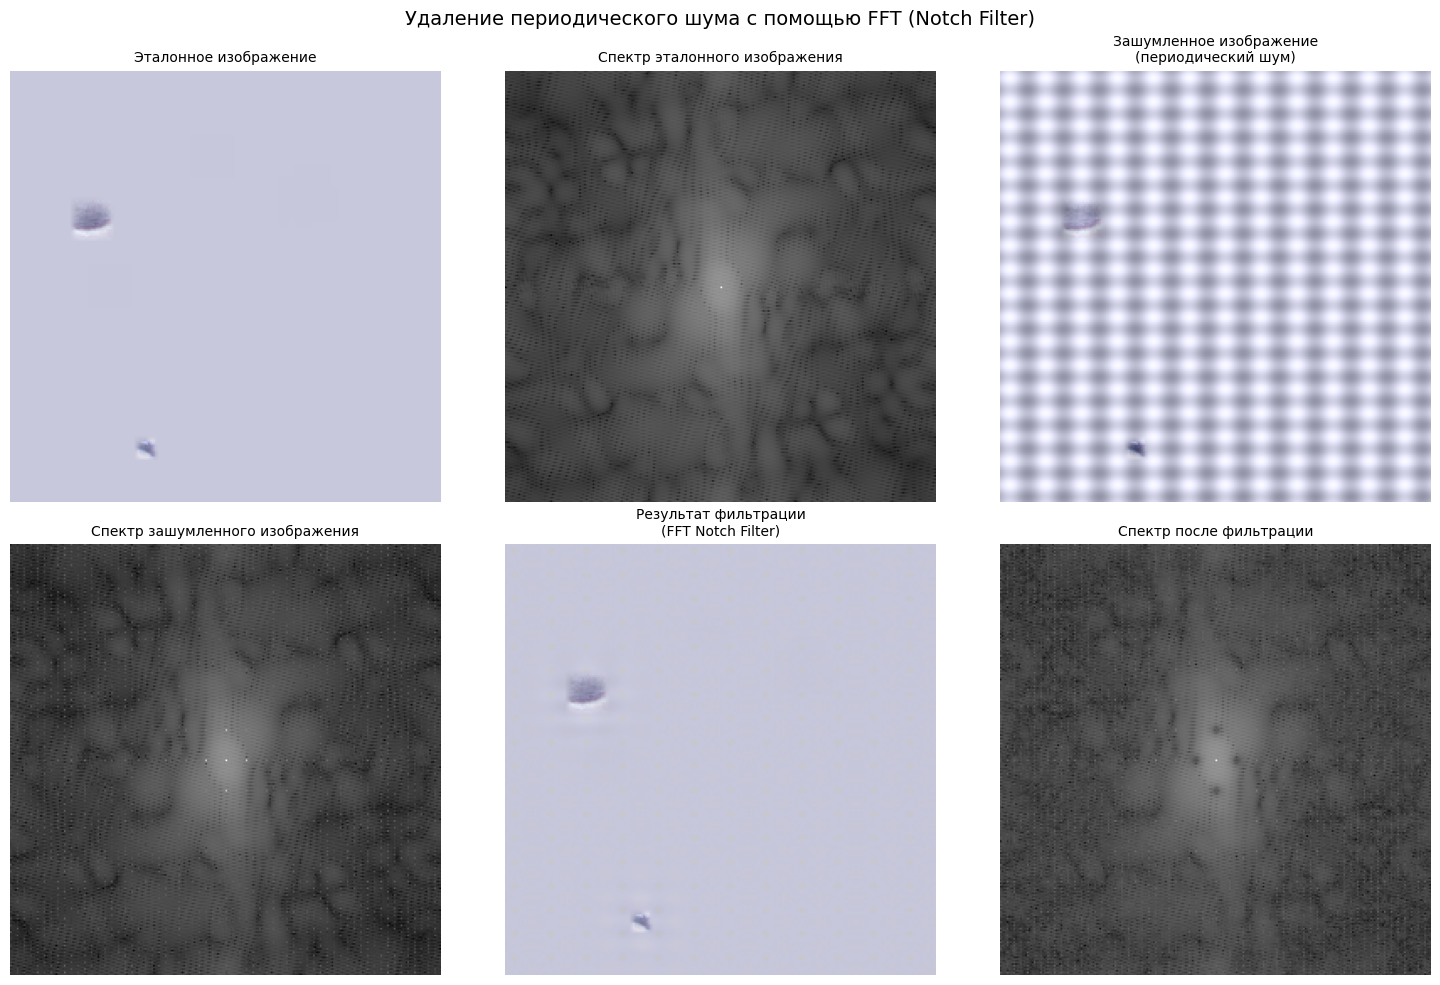

In [14]:
dataset_example = BloodCellDataset(
    img_size=(256, 256), dataset_size=1,
    bg_patches=bg_patches_list, cell_patches=cell_patches_list,
    noise_type='periodic', use_synthetic=True,
    periodic_freq=15, periodic_amplitude=20
)
clean_img_example, noisy_img_example, _ = dataset_example[0]
denoised_img_example = remove_periodic_noise_fft(noisy_img_example,) 
visualize_fourier_denoising(clean_img_example, noisy_img_example, denoised_img_example)

# Cжатие изображений (Haar + RLE)

In [16]:
image_path = 'sar_1_gray.jpg' # 'example.png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
print(img.shape)

(400, 600)


In [17]:
def haar_wavelet_transform(img):
    img = img.astype(np.float32)
    h, w = img.shape
    temp = np.zeros_like(img)
    norm = np.sqrt(2)

    for i in range(h):
        row = img[i]
        avg = (row[0::2] + row[1::2]) / norm
        diff = (row[0::2] - row[1::2]) / norm
        temp[i, :w//2] = avg
        temp[i, w//2:] = diff
    result = np.zeros_like(temp)

    for j in range(w):
        col = temp[:, j]
        avg = (col[0::2] + col[1::2]) / norm
        diff = (col[0::2] - col[1::2]) / norm
        result[:h//2, j] = avg
        result[h//2:, j] = diff

    return result


In [18]:
def inverse_haar_wavelet(coeffs):
    coeffs = coeffs.astype(np.float32)
    h, w = coeffs.shape
    temp = np.zeros_like(coeffs)
    norm = np.sqrt(2)

    for j in range(w):
        avg = coeffs[:h//2, j]
        diff = coeffs[h//2:, j]
        temp[0::2, j] = (avg + diff) / norm
        temp[1::2, j] = (avg - diff) / norm
    result = np.zeros_like(temp)

    for i in range(h):
        avg = temp[i, :w//2]
        diff = temp[i, w//2:]
        result[i, 0::2] = (avg + diff) / norm
        result[i, 1::2] = (avg - diff) / norm

    return np.clip(result, 0, 255).astype(np.uint8)


In [19]:
def threshold_wavelet(coeffs, threshold=15):
    result = coeffs.copy()
    h, w = coeffs.shape
    hl = result[:h//2, w//2:]
    lh = result[h//2:, :w//2]
    hh = result[h//2:, w//2:]
    hl[np.abs(hl) < threshold] = 0
    lh[np.abs(lh) < threshold] = 0
    hh[np.abs(hh) < threshold] = 0

    return result

In [20]:
def rle_encode(data):
    encoded = []
    zero_count = 0
    
    for value in data.flatten():
        value = int(round(value))
        if value == 0:
            zero_count += 1
        else:
            encoded.append((zero_count, value))
            zero_count = 0

    return encoded


In [21]:
def save_rle(encoded_data, filename):
    with open(filename, 'w') as f:
        for zeros, value in encoded_data:
            f.write(f'{zeros} {value}\n')


In [22]:
coeffs = haar_wavelet_transform(img)

compressed_coeffs = threshold_wavelet(coeffs, threshold=15)
compressed_coeffs = np.round(compressed_coeffs).astype(np.int16)

restored = inverse_haar_wavelet(compressed_coeffs)

encoded = rle_encode(compressed_coeffs)

save_rle(encoded, 'compressed.txt')

print('RLE pairs:', len(encoded))


RLE pairs: 124125


In [23]:
original_size = img.nbytes # os.path.getsize(image_path)
compressed_size = os.path.getsize('compressed.txt')

ratio = original_size / compressed_size

print('Original:', original_size)
print('Compressed:', compressed_size)
print('Compression ratio:', round(ratio, 2))


Original: 240000
Compressed: 822513
Compression ratio: 0.29


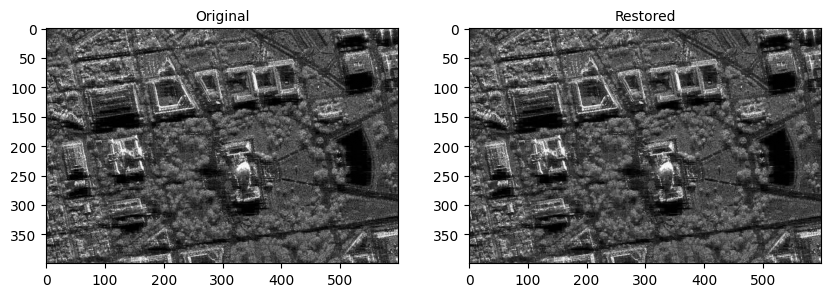

In [24]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(restored, cmap='gray')
plt.title('Restored')

plt.show()


In [ ]:
compression_ratios = []
wavelet_ssim = []
wavelet_mse = []

example_dataset = BloodCellDataset(
    img_size=(256, 256), dataset_size=100,
    bg_patches=bg_patches_list, cell_patches=cell_patches_list,
    noise_type='periodic', use_synthetic=True,
    periodic_freq=15, periodic_amplitude=20
)

for i in range(len(example_dataset)):
    clean_img, noisy_img, _ = dataset_example[i]
    filtered_img = remove_periodic_noise_fft(noisy_img)

    # wavelet comprassion
    gray = cv2.cvtColor(filtered_img, cv2.COLOR_BGR2GRAY)
    coeffs = haar_wavelet_transform(gray)
    threshold = np.std(coeffs)*0.8
    compressed_coeffs = threshold_wavelet(coeffs, threshold=threshold)
    compressed_coeffs = np.round(compressed_coeffs).astype(np.int16)
    encoded = rle_encode(compressed_coeffs)

    # comprassion ratio
    original_size = gray.nbytes
    compressed_size = len(encoded) * 6
    ratio = (original_size /compressed_size)
    compression_ratios.append(ratio)

    restored = inverse_haar_wavelet(compressed_coeffs)

    # метрики
    mse_value = mean_squared_error(gray,restored)
    ssim_value = ssim(gray,restored,data_range=255)
    wavelet_mse.append(mse_value)
    wavelet_ssim.append(ssim_value)

In [27]:
print('Average compression ratio', np.mean(compression_ratios))
print('Average wavelet MSE', np.mean(wavelet_mse))
print('Average wavelet SSIM', np.mean(wavelet_ssim))

Average compression ratio 0.6666666666666669
Average wavelet MSE 1.8914314270019532
Average wavelet SSIM 0.9855909463525856
